# Verify config interpolation (time-varying OP configs)

**Purpose:** confirm that time-varying simulation configs (e.g. OP08 `fluid_inlet_temp`, given as only **4 points**) are correctly **linearly interpolated** onto the dense simulation time axis (`t_fast`).

This notebook is a **verification harness**: it reads the raw files directly and applies `np.interp` itself, so you can check the interpolation is right **before** it is wired into `config_resolve.py`. It does **not** use the cache or `config_resolve.py`.

Key facts (verified in code):
- Profile channels are stored raw as `(times, values)` — nothing in the codebase interpolates yet (`grep np.interp` = 0 hits).
- `config_resolve.resolve_config_channel` will use plain **linear** `np.interp(t_fast, times, values)`.
- Clean OPs (OP01–07, OP14, OP16) have **constant** configs — nothing varies in time. OP02 is clean, so its config does *not* vary (only the simulated current/voltage do).
- The only time-varying config for OP08 is `fluid_inlet_temp` (`Temperaturprofil`, 4 points).
- OP19 now includes `c_rate` in its ModuleTestData source and is detected in this notebook.

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_data_raw() -> Path:
    """Walk up from the current dir to find the data_raw folder."""
    here = Path.cwd()
    for base in (here, *here.parents):
        candidate = base / "data_raw"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError("Could not locate data_raw/ above the current directory")


DATA_RAW = _find_data_raw()
CSV_ENCODING = "cp1252"

# Profile-file glob patterns per channel (mirrors schema.mapping.resolve_profile_source).
# c_rate has no standalone *(t) profile file pattern in v1; it can still come from ModuleTestData.
PROFILE_PATTERNS = {
    "cell_current": ["*_CellCurrent(t).csv"],
    "fluid_mass_flow": ["*_FluidMassFlow(t).csv"],
    "fluid_inlet_temp": ["*_FluidInletTemperature(t).csv", "*_FluidInletTemperatur(t).xlsx"],
}
# Time-series channels to inspect in this notebook.
TIME_SERIES_CHANNELS = ("c_rate", "cell_current", "fluid_mass_flow", "fluid_inlet_temp")

# Human-readable axis labels.
CHANNEL_UNITS = {
    "c_rate": "C-rate (1/h)",
    "cell_current": "Cell current (A)",
    "fluid_mass_flow": "Fluid mass flow (kg/s)",
    "fluid_inlet_temp": "Fluid inlet temperature (°C)",
}
# Candidate value-column names per channel (mirrors raw_readers.read_time_series_input/module_test_data).
VALUE_CANDIDATES = {
    "c_rate": ["C-Rate Monitor (1/h)", "C-Rate (1/h)", "C-Rate", "c_rate", "crate"],
    "cell_current": ["Cell Current (A)", "Cell Current Monitor (A)"],
    "fluid_mass_flow": ["Fluid Mass Flow (kg/s)", "Fluid Mass Flow Monitor (kg/s)"],
    "fluid_inlet_temp": ["Fluid Inlet Temperature (C)", "Fluid Inlet Temperatur (C)"],
}

print("data_raw:", DATA_RAW)
print("OPs found:", sorted(p.name for p in DATA_RAW.iterdir() if p.is_dir()))

data_raw: c:\Users\M0245635\batterysurrogatemodell\battery_surrogate_agenticWorkflow\data_raw
OPs found: ['OP01', 'OP02', 'OP03', 'OP04', 'OP05', 'OP06', 'OP07', 'OP08', 'OP09', 'OP10', 'OP11', 'OP12', 'OP13', 'OP14', 'OP15', 'OP16', 'OP19']


In [12]:
def op_inner_dir(op_id: str) -> Path:
    """Return data_raw/OPxx/OPxx (the nested folder that holds the CSVs)."""
    return DATA_RAW / op_id / op_id


def find_profile_file(op_id: str, channel: str) -> Path | None:
    inner = op_inner_dir(op_id)
    if not inner.is_dir():
        return None
    for pattern in PROFILE_PATTERNS.get(channel, []):
        matches = sorted(inner.glob(pattern))
        if matches:
            return matches[0]
    return None


def find_module_test_file(op_id: str) -> Path | None:
    """Find module-test CSV, including suffixed exports like *(in).csv."""
    inner = op_inner_dir(op_id)
    if not inner.is_dir():
        return None
    matches = sorted(inner.glob("*_ModuleTestData*.csv"))
    return matches[0] if matches else None


def _columns_have_any(frame: pd.DataFrame, candidates: list[str]) -> bool:
    lowered = {str(c).casefold() for c in frame.columns}
    return any(c.casefold() in lowered for c in candidates)


def classify_ops() -> pd.DataFrame:
    rows = []
    for op_dir in sorted(DATA_RAW.iterdir()):
        if not op_dir.is_dir():
            continue
        op_id = op_dir.name
        has_file = {ch: find_profile_file(op_id, ch) is not None for ch in PROFILE_PATTERNS}
        has_mt = find_module_test_file(op_id) is not None
        if any(has_file.values()):
            kind = "profile"
        elif has_mt:
            kind = "module_test"
        else:
            kind = "clean"

        mt_frame = None
        if has_mt:
            mt_path = find_module_test_file(op_id)
            if mt_path is not None:
                mt_frame = pd.read_csv(mt_path, encoding=CSV_ENCODING) if mt_path.suffix.lower() != ".xlsx" else pd.read_excel(mt_path, engine="openpyxl")

        present = {}
        for ch in TIME_SERIES_CHANNELS:
            in_profile = has_file.get(ch, False)
            in_module = bool(mt_frame is not None and _columns_have_any(mt_frame, VALUE_CANDIDATES[ch]))
            present[ch] = in_profile or in_module

        rows.append({"op_id": op_id, "kind": kind, **{f"has_{k}": v for k, v in present.items()}})
    return pd.DataFrame(rows)


registry = classify_ops()
registry

,op_id,kind,has_c_rate,has_cell_current,has_fluid_mass_flow,has_fluid_inlet_temp
0,OP01,clean,False,False,False,False
1,OP02,clean,False,False,False,False
2,OP03,clean,False,False,False,False
3,OP04,clean,False,False,False,False
4,OP05,clean,False,False,False,False
5,OP06,clean,False,False,False,False
6,OP07,clean,False,False,False,False
7,OP08,profile,False,False,False,True
8,OP09,profile,False,False,False,True
9,OP10,profile,False,True,False,False


In [13]:
def _read_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".xlsx":
        return pd.read_excel(path, engine="openpyxl")
    return pd.read_csv(path, encoding=CSV_ENCODING)


def _time_column(frame: pd.DataFrame) -> str:
    for col in frame.columns:
        if "time" in str(col).casefold():
            return col
    raise KeyError(f"No time-like column in {list(frame.columns)!r}")


def _has_value_column(frame: pd.DataFrame, channel: str) -> bool:
    lowered = {str(c).casefold() for c in frame.columns}
    return any(cand.casefold() in lowered for cand in VALUE_CANDIDATES[channel])


def _value_column(frame: pd.DataFrame, channel: str, time_col: str) -> str:
    lowered = {str(c).casefold(): c for c in frame.columns}
    for cand in VALUE_CANDIDATES[channel]:
        if cand.casefold() in lowered:
            return lowered[cand.casefold()]
    # fallback: first numeric column that is not the time column
    for col in frame.columns:
        if col == time_col:
            continue
        if pd.api.types.is_numeric_dtype(frame[col]):
            return col
    raise KeyError(f"No value column for {channel} in {list(frame.columns)!r}")


def channel_source(op_id: str, channel: str) -> tuple[Path | None, str | None]:
    """Where a channel's time series lives: a *(t) profile file, or ModuleTestData."""
    profile_path = find_profile_file(op_id, channel)
    if profile_path is not None:
        return profile_path, "profile"
    mt_path = find_module_test_file(op_id)
    if mt_path is not None and _has_value_column(_read_table(mt_path), channel):
        return mt_path, "module_test"
    return None, None


def read_profile(op_id: str, channel: str) -> tuple[np.ndarray, np.ndarray, str]:
    """Return (times, values, source_filename) for one time-varying channel."""
    path, _ = channel_source(op_id, channel)
    if path is None:
        raise FileNotFoundError(f"No {channel} time series for {op_id}")
    frame = _read_table(path)
    tcol = _time_column(frame)
    vcol = _value_column(frame, channel, tcol)
    times = frame[tcol].to_numpy(dtype=np.float64)
    values = frame[vcol].to_numpy(dtype=np.float64)
    return times, values, path.name


def read_t_fast(op_id: str) -> np.ndarray:
    """Dense simulation time axis from the FMU1 file (what config_resolve targets)."""
    inner = op_inner_dir(op_id)
    matches = sorted(inner.glob("*_Batemo FMU1.csv"))
    if not matches:
        raise FileNotFoundError(f"No FMU1 file for {op_id}")
    frame = pd.read_csv(matches[0], encoding=CSV_ENCODING)
    tcol = _time_column(frame)
    return frame[tcol].to_numpy(dtype=np.float64)


def clean_monotonic(times: np.ndarray, values: np.ndarray) -> tuple[np.ndarray, np.ndarray, bool]:
    """Sort by time and collapse duplicate timestamps (mean value). Returns (t, v, had_dupes)."""
    order = np.argsort(times, kind="stable")
    times, values = times[order], values[order]
    uniq, idx = np.unique(times, return_inverse=True)
    had_dupes = uniq.size != times.size
    if had_dupes:
        agg = np.zeros(uniq.size)
        counts = np.zeros(uniq.size)
        np.add.at(agg, idx, values)
        np.add.at(counts, idx, 1.0)
        values = agg / counts
        times = uniq
    return times, values, had_dupes


def linear_interp(t_axis: np.ndarray, times: np.ndarray, values: np.ndarray) -> np.ndarray:
    """Plain linear interpolation, clamped at the endpoints (np.interp default)."""
    times, values, _ = clean_monotonic(times, values)
    assert np.all(np.diff(times) > 0), "profile time axis still not strictly increasing after cleanup"
    return np.interp(t_axis, times, values)


print("helpers ready")

helpers ready


14 time-varying (op, channel) pairs
Display scales: cell_current->kA, fluid_mass_flow->g/s, c_rate->1/h, temperature->°C


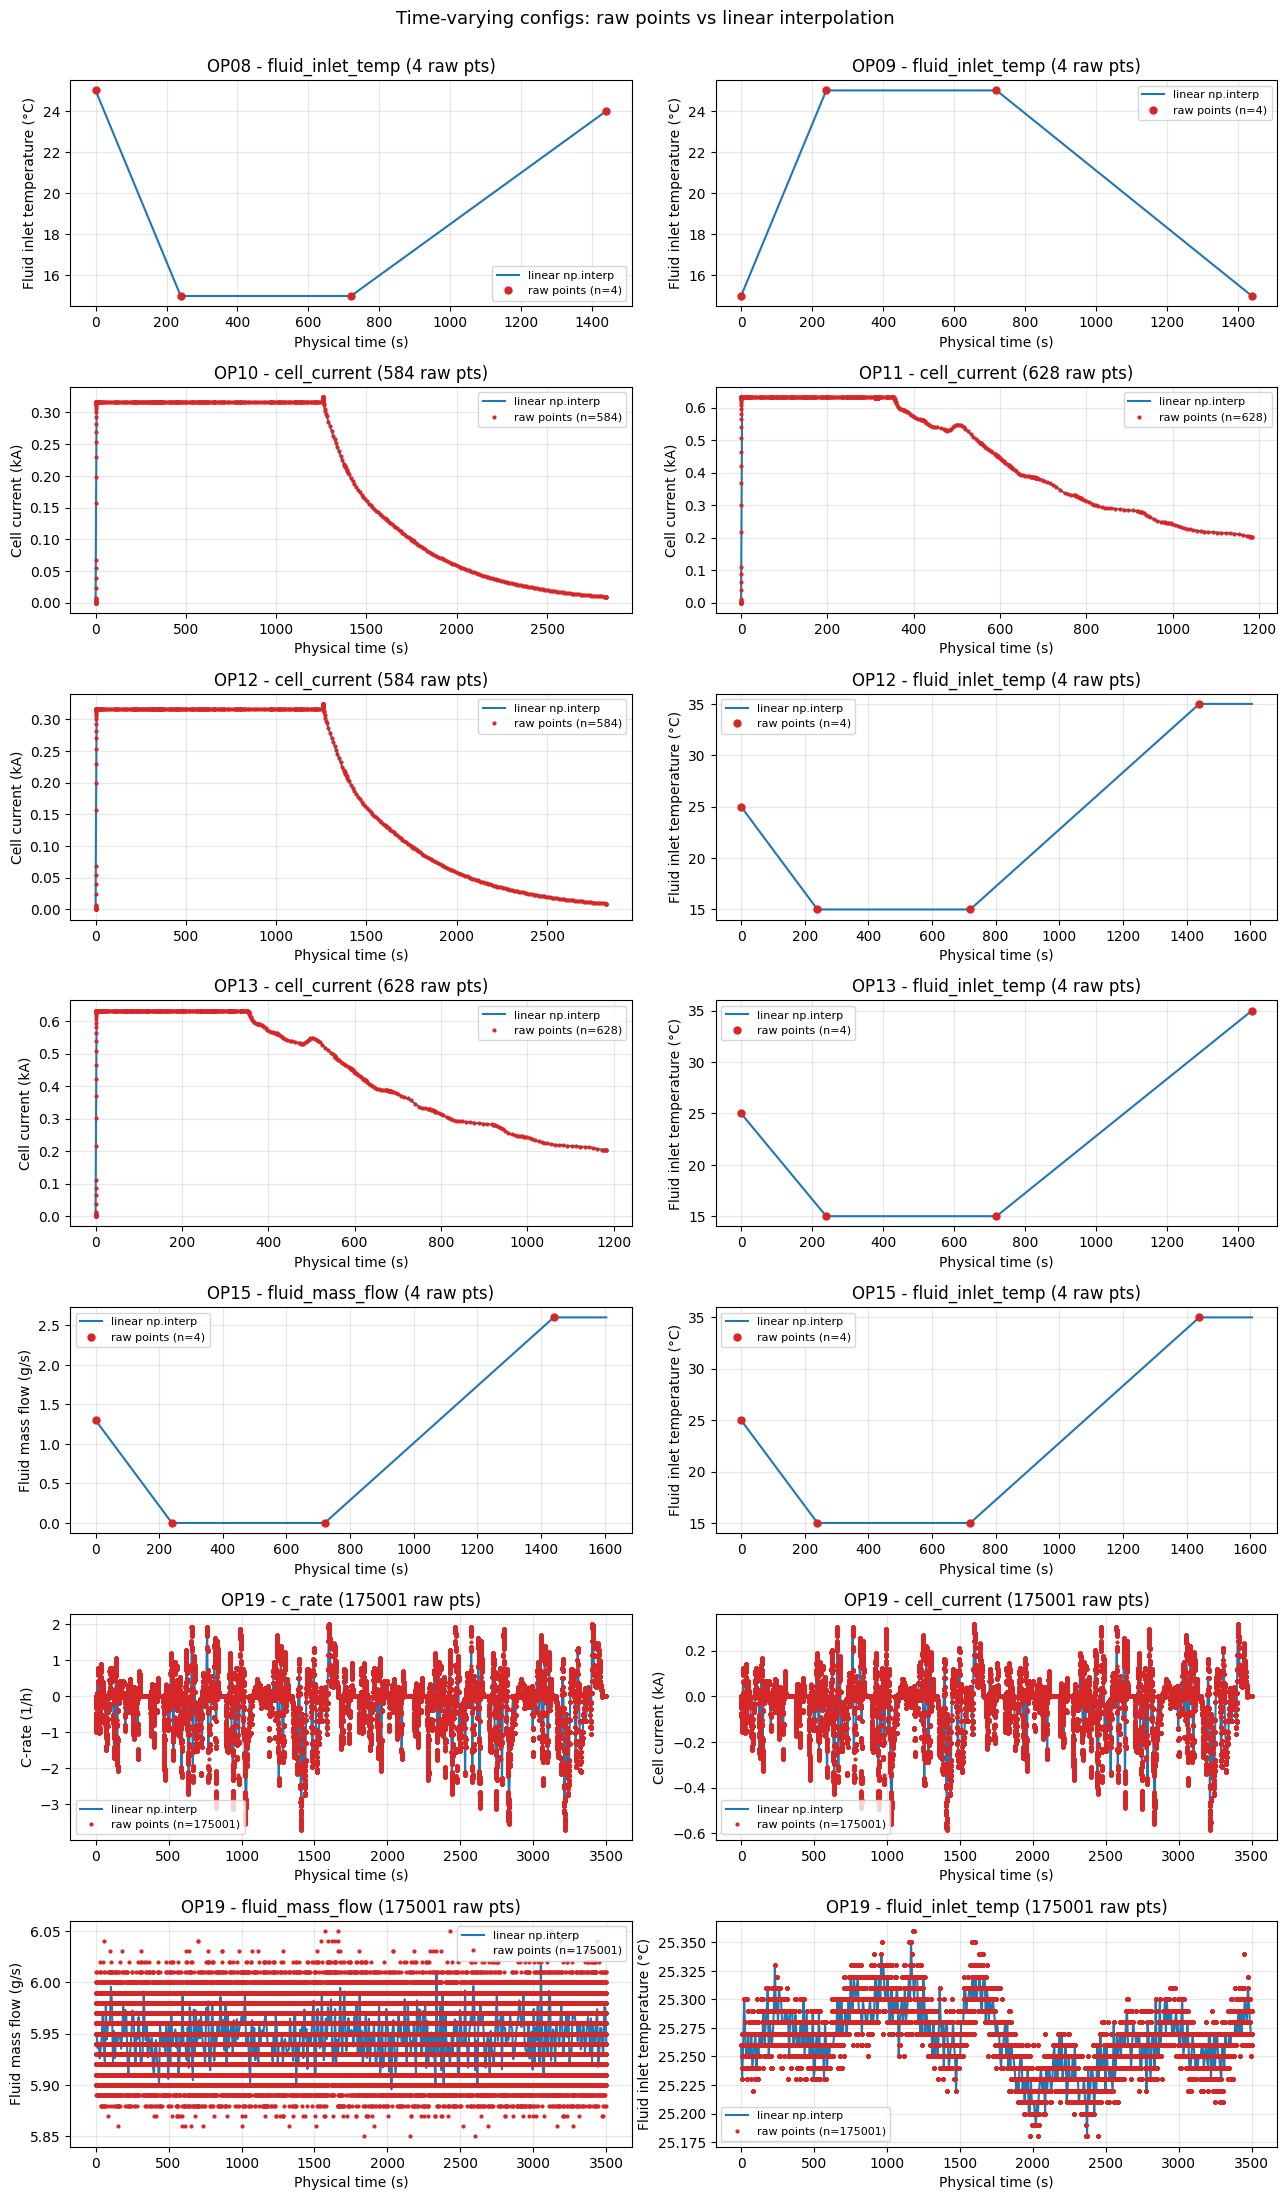


[WARNING] profiles with duplicate/non-strictly-increasing timestamps (collapsed by mean):
  OP11 cell_current: OP11_CellCurrent(t).csv (628 raw rows)
  OP13 cell_current: OP13_CellCurrent(t).csv (628 raw rows)
  -> config_resolve.py must handle this (its plan currently asserts STRICTLY increasing and would raise).

--- OP19 c_rate diagnostics ---
[OK] Found OP19 c-rate column: C-Rate (1/h)


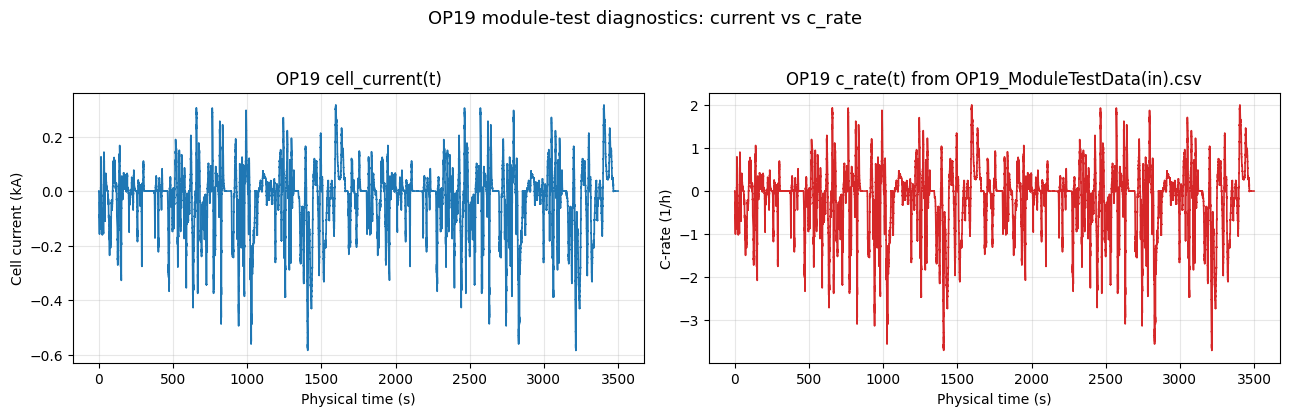

Columns in OP19 ModuleTestData: ['Physical Time (s)', 'Cell Current (A)', 'Fluid Mass Flow (kg/s)', 'Fluid Inlet Temperature (C)', 'Unnamed: 4', 'C-Rate (1/h)']


In [17]:
# Plot every time-varying config (profile OPs + module-test OPs like OP19),
# one subplot per (op, channel) that actually has a time series.
# Unified display units across all plots for readability/comparison.
plot_rows = registry[registry["kind"].isin(["profile", "module_test"])]
tasks = []
for op_id in plot_rows["op_id"]:
    for channel in TIME_SERIES_CHANNELS:
        if channel_source(op_id, channel)[0] is not None:
            tasks.append((op_id, channel))

# Channel-specific display scales: plotted_value = raw_value * factor
DISPLAY_SCALE = {
    "c_rate": (1.0, "C-rate (1/h)"),
    "cell_current": (1.0 / 1000.0, "Cell current (kA)"),
    "fluid_mass_flow": (1000.0, "Fluid mass flow (g/s)"),
    "fluid_inlet_temp": (1.0, "Fluid inlet temperature (°C)"),
}

n = len(tasks)
print(f"{n} time-varying (op, channel) pairs")
print("Display scales: cell_current->kA, fluid_mass_flow->g/s, c_rate->1/h, temperature->°C")
ncols = 2
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

dupe_report = []
for i, (op_id, channel) in enumerate(tasks):
    ax = axes.flat[i]
    ax.set_visible(True)
    times, values, src = read_profile(op_id, channel)
    _, _, had_dupes = clean_monotonic(times, values)
    if had_dupes:
        dupe_report.append((op_id, channel, src, len(times)))

    t_fast = read_t_fast(op_id)
    t_dense = np.linspace(float(min(times[0], t_fast[0])), float(max(times[-1], t_fast[-1])), 500)
    interp = linear_interp(t_dense, times, values)

    scale_factor, y_label = DISPLAY_SCALE.get(channel, (1.0, CHANNEL_UNITS.get(channel, channel)))
    values_plot = values * scale_factor
    interp_plot = interp * scale_factor

    marker_size = 5 if len(times) <= 60 else 2
    ax.plot(t_dense, interp_plot, "-", color="C0", label="linear np.interp")
    ax.plot(times, values_plot, "o", color="C3", markersize=marker_size, label=f"raw points (n={len(times)})")
    ax.set_title(f"{op_id} - {channel} ({len(times)} raw pts)")
    ax.set_xlabel("Physical time (s)")
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Time-varying configs: raw points vs linear interpolation", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

if dupe_report:
    print("\n[WARNING] profiles with duplicate/non-strictly-increasing timestamps (collapsed by mean):")
    for op_id, channel, src, npts in dupe_report:
        print(f"  {op_id} {channel}: {src} ({npts} raw rows)")
    print("  -> config_resolve.py must handle this (its plan currently asserts STRICTLY increasing and would raise).")
else:
    print("\nAll profile time axes are strictly increasing.")

# OP19 c_rate diagnostics in the same Cell 5 output block (not a separate cell).
print("\n--- OP19 c_rate diagnostics ---")
op_id = "OP19"
mt_path = find_module_test_file(op_id)
if mt_path is None:
    raise FileNotFoundError(f"No ModuleTestData file found for {op_id}")

frame = _read_table(mt_path)
tcol = _time_column(frame)

def _find_col(candidates: list[str]) -> str | None:
    lowered = {str(c).casefold(): c for c in frame.columns}
    for cand in candidates:
        key = cand.casefold()
        if key in lowered:
            return lowered[key]
    return None

c_rate_candidates = ["C-Rate Monitor (1/h)", "C-Rate (1/h)", "C-Rate", "c_rate", "crate"]
i_col = _find_col(["Cell Current (A)", "Cell Current Monitor (A)"])
c_rate_col = _find_col(c_rate_candidates)

t = frame[tcol].to_numpy(dtype=np.float64)
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4.2))

if i_col is not None:
    i_vals = frame[i_col].to_numpy(dtype=np.float64)
    i_factor, i_label = DISPLAY_SCALE["cell_current"]
    axes2[0].plot(t, i_vals * i_factor, color="C0", lw=1.2)
    axes2[0].set_title(f"{op_id} cell_current(t)")
    axes2[0].set_xlabel("Physical time (s)")
    axes2[0].set_ylabel(i_label)
    axes2[0].grid(True, alpha=0.3)
else:
    axes2[0].text(0.5, 0.5, "No cell_current column found", ha="center", va="center")
    axes2[0].set_title(f"{op_id} cell_current(t)")
    axes2[0].set_axis_off()

if c_rate_col is not None:
    c_vals = frame[c_rate_col].to_numpy(dtype=np.float64)
    c_factor, c_label = DISPLAY_SCALE["c_rate"]
    axes2[1].plot(t, c_vals * c_factor, color="C3", lw=1.2)
    axes2[1].set_title(f"{op_id} c_rate(t) from {mt_path.name}")
    axes2[1].set_xlabel("Physical time (s)")
    axes2[1].set_ylabel(c_label)
    axes2[1].grid(True, alpha=0.3)
    print(f"[OK] Found OP19 c-rate column: {c_rate_col}")
else:
    axes2[1].text(0.5, 0.55, "OP19 c_rate column not found\nin ModuleTestData", ha="center", va="center")
    axes2[1].text(
        0.5,
        0.36,
        "Provide numeric c_rate time-series\nto enable OP19 c_rate feature",
        ha="center",
        va="center",
        fontsize=9,
        color="C3",
    )
    axes2[1].set_title(f"{op_id} c_rate(t)")
    axes2[1].set_axis_off()
    print("[BLOCKER] OP19 c_rate data is still missing in ModuleTestData.")

fig2.suptitle(f"{op_id} module-test diagnostics: current vs c_rate", fontsize=13)
fig2.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()
print("Columns in OP19 ModuleTestData:", list(frame.columns))

In [18]:
# Duplicate-time diagnostics for OP11 and OP13 profile files.
for op_id in ["OP11", "OP13"]:
    path = find_profile_file(op_id, "cell_current")
    if path is None:
        print(f"{op_id}: no cell_current profile file found")
        continue

    frame = _read_table(path)
    tcol = _time_column(frame)
    times = frame[tcol].to_numpy(dtype=np.float64)
    uniq, counts = np.unique(times, return_counts=True)
    dup_times = uniq[counts > 1]

    print(f"\n{op_id}")
    print(f"  file: {path.name}")
    print(f"  rows: {len(times)}")
    print(f"  unique times: {len(uniq)}")
    print(f"  duplicate timestamps (unique): {len(dup_times)}")

    if len(dup_times) > 0:
        # Show first 20 duplicate time values with their multiplicities.
        dup_counts = counts[counts > 1]
        preview_n = min(20, len(dup_times))
        print("  first duplicate times [time_s: occurrences]:")
        for t, c in zip(dup_times[:preview_n], dup_counts[:preview_n]):
            print(f"    {t:.6g}: {int(c)}")

        # Show contiguous duplicate-time ranges for quick interpretation.
        # Many duplicates are a repeated t=0 startup block in these files.
        starts = [dup_times[0]]
        ends = []
        for i in range(1, len(dup_times)):
            if not np.isclose(dup_times[i] - dup_times[i - 1], 1.0):
                ends.append(dup_times[i - 1])
                starts.append(dup_times[i])
        ends.append(dup_times[-1])

        print("  duplicate-time ranges (approx):")
        for s, e in zip(starts[:10], ends[:10]):
            if np.isclose(s, e):
                print(f"    {s:.6g}")
            else:
                print(f"    {s:.6g} .. {e:.6g}")
    else:
        print("  no duplicate timestamps")


OP11
  file: OP11_CellCurrent(t).csv
  rows: 628
  unique times: 627
  duplicate timestamps (unique): 1
  first duplicate times [time_s: occurrences]:
    1183.46: 2
  duplicate-time ranges (approx):
    1183.46

OP13
  file: OP13_CellCurrent(t).csv
  rows: 628
  unique times: 627
  duplicate timestamps (unique): 1
  first duplicate times [time_s: occurrences]:
    1183.46: 2
  duplicate-time ranges (approx):
    1183.46
